<a href="https://colab.research.google.com/github/mdonbruce/AspNetDocs/blob/master/MiniLab5_Colab_ML_Instructor_EXECUTED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini‑Lab 5 — Instructor EXECUTED

In [2]:
import pandas as pd, numpy as np
DATA_PATH=r'/content/retail_churn_ml_large.csv'
df=pd.read_csv(DATA_PATH)
print('raw', df.shape)
df.head()

raw (55000, 8)


,customer_id,region,tenure_months,avg_order_value,orders_last_90d,support_tickets_90d,discount_rate_avg,churned
0,500000,SW,5,46.80,11,0,0.048,1
1,500001,MW,28,22.60,10,4,0.339,0
2,500002,PNW,38,39.57,5,0,0.346,0
3,500003,W,54,79.88,13,4,0.032,0
4,500004,W,7,53.04,15,5,0.137,0


In [4]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

df2=df.copy()
df2['region']=df2['region'].astype('string').fillna('UNKNOWN').str.strip().replace({'':'UNKNOWN'})
df2['tenure_months']=pd.to_numeric(df2['tenure_months'], errors='coerce')
df2=df2[df2['tenure_months'].notna() & (df2['tenure_months']>=0)]
df2['discount_rate_avg']=pd.to_numeric(df2['discount_rate_avg'], errors='coerce').fillna(0.0).clip(0,0.60)
df2['avg_order_value']=pd.to_numeric(df2['avg_order_value'], errors='coerce')
df2['avg_order_value']=df2['avg_order_value'].fillna(df2['avg_order_value'].median())
df2['orders_last_90d']=pd.to_numeric(df2['orders_last_90d'], errors='coerce').fillna(0)
df2['support_tickets_90d']=pd.to_numeric(df2['support_tickets_90d'], errors='coerce').fillna(0)
df2['churned']=pd.to_numeric(df2['churned'], errors='coerce').fillna(0).astype(int)

X=df2[['region','tenure_months','avg_order_value','orders_last_90d','support_tickets_90d','discount_rate_avg']]
y=df2['churned']
pre=ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), ['region'])], remainder='passthrough')
model=Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=500))])
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
model.fit(X_train,y_train)
pred=model.predict(X_test)
acc=accuracy_score(y_test,pred)
cm=confusion_matrix(y_test,pred)
acc, cm


(0.8732846715328467,
 array([[11962,     7],
        [ 1729,     2]]))

### Confusion Matrix Visualization

Let's visualize the confusion matrix to get a clearer picture of the model's true positives, true negatives, false positives, and false negatives.

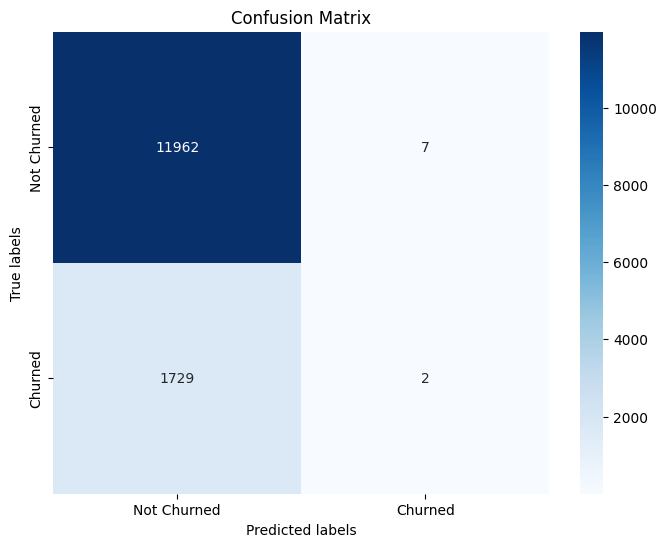

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Assuming `cm` is already defined from the previous cell's execution
# If not, you would re-calculate it:
# from sklearn.metrics import confusion_matrix
# cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['Not Churned', 'Churned'])
ax.yaxis.set_ticklabels(['Not Churned', 'Churned'])
plt.show()

### Receiver Operating Characteristic (ROC) Curve

The ROC curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. The Area Under the Curve (AUC) is a measure of the overall performance of the classifier.

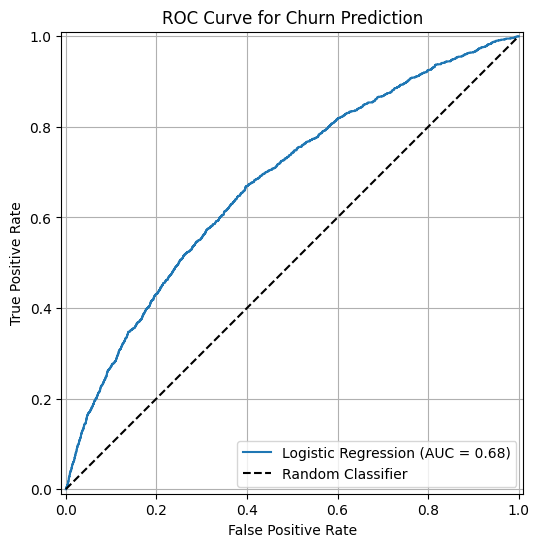

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# Get probability predictions for the positive class (churned)
# model.predict_proba returns probabilities for [class_0, class_1]
probabilities = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

# Calculate AUC score
roc_auc = roc_auc_score(y_test, probabilities)

# Plot the ROC curve
fig, ax = plt.subplots(figsize=(8, 6))
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='Logistic Regression')
roc_display.plot(ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Add a diagonal random classifier line
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve for Churn Prediction')
ax.legend(loc='lower right')
plt.grid(True)
plt.show()